# Multimode Cross-Kerr Phase Accumulation


This notebook rewrites `examples/multimode_crosskerr_demo.py` as an advanced three-mode tutorial. We prepare a superposition of storage Fock states while the readout mode contains one photon, then let the system evolve freely under a storage-readout cross-Kerr interaction.

The physical observable is a conditional phase. Cross-Kerr does not transfer population here; it changes the relative phase between the storage branches at a rate set by `chi_sr`.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveReadoutTransmonStorageModel,
    FrameSpec,
    SequenceCompiler,
    SimulationConfig,
    simulate_sequence,
)
from tutorials.tutorial_support import GHz, MHz, ns


## Physics / model definition


In [2]:
chi_sr = MHz(1.5)
final_phase_rad = 1.12
evolution_time_s = final_phase_rad / chi_sr

model = DispersiveReadoutTransmonStorageModel(
    omega_s=GHz(5.0),
    omega_r=GHz(7.5),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi_s=0.0,
    chi_r=0.0,
    chi_sr=chi_sr,
    kerr_s=0.0,
    kerr_r=0.0,
    n_storage=3,
    n_readout=3,
    n_tr=2,
)
frame = FrameSpec(
    omega_c_frame=model.omega_s,
    omega_q_frame=model.omega_q,
    omega_r_frame=model.omega_r,
)
initial_state = (model.basis_state(0, 0, 1) + model.basis_state(0, 1, 1)).unit()
times_ns = np.linspace(0.0, evolution_time_s / ns, 31)


## Pulse / sequence construction


In [3]:
def relative_phase_after(time_s: float) -> float:
    if time_s <= 0.0:
        state = initial_state
    else:
        compiled = SequenceCompiler(dt=max(0.5 * ns, time_s / 150.0)).compile([], t_end=time_s)
        result = simulate_sequence(
            model,
            compiled,
            initial_state,
            {},
            config=SimulationConfig(frame=frame),
        )
        state = result.final_state
    amp_ref = model.basis_state(0, 0, 1).overlap(state)
    amp_shifted = model.basis_state(0, 1, 1).overlap(state)
    return float(np.angle(amp_shifted / amp_ref))


## Simulation


In [4]:
relative_phase_rad = np.asarray([relative_phase_after(time_ns * ns) for time_ns in times_ns], dtype=float)
expected_phase_rad = np.asarray(
    [float(np.angle(np.exp(-1j * chi_sr * time_ns * ns))) for time_ns in times_ns],
    dtype=float,
)

print("Final simulated phase [rad]:", float(relative_phase_rad[-1]))
print("Final expected phase [rad]:", float(expected_phase_rad[-1]))


Final simulated phase [rad]: -1.120000872981392
Final expected phase [rad]: -1.12


## Analysis / visualization


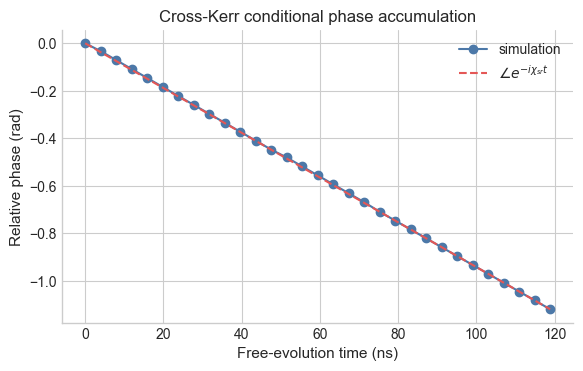

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(times_ns, relative_phase_rad, "o-", label="simulation", color="#4C78A8")
ax.plot(times_ns, expected_phase_rad, "--", label=r"$\angle e^{-i \chi_{sr} t}$", color="#E45756")
ax.set_xlabel("Free-evolution time (ns)")
ax.set_ylabel("Relative phase (rad)")
ax.set_title("Cross-Kerr conditional phase accumulation")
ax.legend(loc="best")
plt.show()


## Interpretation


The storage and readout populations stay fixed, but the branch with one storage photon accumulates an extra phase because the readout is occupied. That is exactly what a cross-Kerr term is supposed to do in this effective model.

This notebook is a useful sanity check whenever you need to interpret three-mode conditional phases or when you want to calibrate a wait-based controlled-phase primitive.


## Variations / exercises


- Repeat the calculation with the readout in vacuum to confirm that the conditional phase disappears.
- Add storage self-Kerr or readout self-Kerr to separate self- and cross-nonlinearity effects.
- Extend the initial state to include two storage photons and compare the phase scaling.
